In [43]:
!pip install pandas scikit-learn matplotlib nltk textblob

In [44]:
# =========================================================
# LEGAL SENTENCE PAIR CLEANING + ANALYSIS PIPELINE
# =========================================================


import os, re, json, logging
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

In [45]:
# =========================================================
# Step 1 — Data Loading
# =========================================================
def parse_lrec_line(line: str):
    parts = line.strip().split("\t")
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2:
        return None
    try:
        sentpair_id = int(parts[0])
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except (ValueError, IndexError):
        return None
    return {"id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

def load_full_data(pos_path, neg_path):
    rows = []
    for filepath in [pos_path, neg_path]:
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                parsed = parse_lrec_line(line)
                if parsed:
                    rows.append(parsed)
    df = pd.DataFrame(rows)
    label_map = {"SUPPORT": 0, "ATTACK": 1, "NO_REL": 2, "NO_REL\n": 2}
    df["label_id"] = df["label"].map(label_map)
    return df.dropna(subset=["sent1", "sent2", "label"]).reset_index(drop=True)

# =========================================================
# Step 2 — Basic Cleaning
# =========================================================
def basic_clean(text: str):
    if not isinstance(text, str):
        return text
    text = re.sub(r'(x{2,}\s*)+', '', text, flags=re.IGNORECASE) # ignore patterns like xxxx xxxx
    text = re.sub(r'\s+', ' ', text).strip() # reduce whitespace
    text = text.replace('“','"').replace('”','"').replace("‘","'").replace("’","'") # standardizing quotes
    return text

# =========================================================
# Step 3 — Legal Reference Normalization
# =========================================================
def fix_legal_references(text: str):
    if not isinstance(text, str):
        return text
    text = re.sub(r'\bI\.\s*P\.\s*C\.\b', 'IPC', text) # Fixing Normal Legal Abbrevations like IPC
    text = re.sub(r'\bCr\.\s*P\.\s*C\.\b', 'CrPC', text)
    text = re.sub(r'\(\s*([^)]+?)\s*\)', r'(\1)', text)
    text = re.sub(r'\b[Ss]\.\s*(\d+)', r'Section \1', text)
    text = re.sub(r'\b[rR]\.\s*(\d+)', r'Rule \1', text)
    return re.sub(r'\s+', ' ', text).strip()

# =========================================================
# Step 4 — Frequency + TF-IDF
# =========================================================
def compute_frequencies(df):
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords')
    eng_stop = set(stopwords.words("english"))
    
    fallback_stopwords = {
        "a","an","the","is","are","was","were","be","been","being","to","of","and",
        "in","on","for","at","by","with","about","as","that","this","it","from","or",
        "but","not","which","who","whom","their","its","they","he","she","we","you",
        "his","her","our","us","them","into","do","does","did","done","can","could",
        "shall","should","will","would","may","might","must","there","here","then",
        "when","where"
    }
    domain_stopwords = {
        "court","appellant","respondent","learned","judge","tribunal","supreme",
        "high","bench","petitioner","case","appeal","section","order","act","rule",
        "laws","provisions","therefore","hence","accordingly","thus","also","said",
        "one","two","three","may","made","stated","observed","whether","since",
        "see","held", "law", "government"
    }
    custom_stopwords = {"would", "however", "wa", "ha"}
    stopset = {w.lower() for w in eng_stop.union(domain_stopwords).union(fallback_stopwords).union(custom_stopwords)} #fallback_stopwords.union(domain_stopwords)}
    tokens = [
        w.lower()
        for text in df["combined_cleaned"]
        for w in re.findall(r"\b[a-zA-Z]{3,}\b", text)
        if w.lower() not in stopset
    ]
    return pd.DataFrame(Counter(tokens).most_common(30), columns=["word","count"])

def compute_tfidf(df):
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords')
    eng_stop = set(stopwords.words("english"))
    
    fallback_stopwords = {
        "a","an","the","is","are","was","were","be","been","being","to","of","and",
        "in","on","for","at","by","with","about","as","that","this","it","from","or",
        "but","not","which","who","whom","their","its","they","he","she","we","you",
        "his","her","our","us","them","into","do","does","did","done","can","could",
        "shall","should","will","would","may","might","must","there","here","then",
        "when","where"
    }
    domain_stopwords = {
        "court","appellant","respondent","learned","judge","tribunal","supreme",
        "high","bench","petitioner","case","appeal","section","order","act","rule",
        "laws","provisions","therefore","hence","accordingly","thus","also","said",
        "one","two","three","may","made","stated","observed","whether","since",
        "see","held", "law", "government"
    }
    custom_stopwords = {"would", "however", "wa", "ha"} #Verbs
    
    stopset = {w.lower() for w in eng_stop.union(domain_stopwords).union(fallback_stopwords).union(custom_stopwords)} #fallback_stopwords.union(domain_stopwords)}
    
    vectorizer = TfidfVectorizer(max_features=5000, stop_words= list(stopset), ngram_range=(1,2)) # "english"
    X = vectorizer.fit_transform(df["combined_cleaned"])
    names = vectorizer.get_feature_names_out()
    overall = pd.DataFrame({"term": names, "tfidf": X.mean(axis=0).A1})\
        .sort_values("tfidf", ascending=False).head(30)
    per_label = []
    for lbl, grp in df.groupby("label"):
        mat = vectorizer.transform(grp["combined_cleaned"])
        vals = mat.mean(axis=0).A1
        sub = pd.DataFrame({"label": lbl, "term": names, "tfidf": vals})\
            .sort_values("tfidf", ascending=False).head(20)
        per_label.append(sub)
    return overall, pd.concat(per_label)

In [46]:
# =========================================================
# Step 5 — Visualizations
# =========================================================
def visualize(freq_df, tfidf_df, tfidf_label_df):
    plt.figure(figsize=(10,6))
    plt.barh(freq_df["word"][::-1], freq_df["count"][::-1])
    plt.title("Top 30 Most Frequent Words ")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(10,6))
    plt.barh(tfidf_df["term"][::-1], tfidf_df["tfidf"][::-1])
    plt.title("Top 20 Overall TF-IDF Terms")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(12,8))
    for i, lbl in enumerate(tfidf_label_df["label"].unique(), start=1):
        subset = tfidf_label_df[tfidf_label_df["label"]==lbl].head(10)
        plt.subplot(3,1,i)
        plt.barh(subset["term"][::-1], subset["tfidf"][::-1])
        plt.title(f"Top 10 TF-IDF Terms — {lbl}")
        plt.tight_layout()
    plt.show()

In [47]:
# =========================================================
# Step 6 — Lemmatization + Sentiment
# =========================================================
def add_lemmatization_and_sentiment(df):
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk.stem import WordNetLemmatizer
    nltk.download('punkt')
    nltk.download('wordnet')
    nltk.download('omw-1.4')

    lemmatizer = WordNetLemmatizer()

    def lemmatize_sentence(txt):
        if not isinstance(txt,str): return txt
        toks = word_tokenize(txt.lower())
        return " ".join(lemmatizer.lemmatize(t) for t in toks if t.isalpha())

    df["sent_lemma"]  = df["sent_cleaned"].apply(lemmatize_sentence)
    df["sent2_lemma"] = df["sent2_cleaned"].apply(lemmatize_sentence)

    def textblob_sentiment(txt):
        if not isinstance(txt,str) or not txt.strip():
            return pd.Series({"polarity":None,"subjectivity":None})
        blob = TextBlob(txt)
        return pd.Series({
            "polarity": blob.sentiment.polarity,
            "subjectivity": blob.sentiment.subjectivity
        })

    sampled = df.sample(2000, random_state=42)
    feats = sampled["sent_lemma"].apply(textblob_sentiment)
    print("\n=== TextBlob Sentiment Summary (sample) ===")
    print(feats.describe().T)
    return df

In [48]:
# =========================================================
# MAIN PIPELINE
# =========================================================
def main(pos_path, neg_path):
    print("Loading data...")
    df = load_full_data(pos_path, neg_path)
    print(f"Loaded {len(df)} rows")

    print("Basic cleaning...")
    df["sent1"] = df["sent1"].apply(basic_clean)
    df["sent2"] = df["sent2"].apply(basic_clean)

    print("Fixing legal references...")
    df["sent_cleaned"]  = df["sent1"].apply(fix_legal_references)
    df["sent2_cleaned"] = df["sent2"].apply(fix_legal_references)

    print("Adding lemmatization + sentiment...")
    df = add_lemmatization_and_sentiment(df)
    
    df["combined_cleaned"] = df["sent_lemma"] + " " + df["sent2_lemma"]


    print("Computing word frequencies and TF-IDF...")
    freq_df = compute_frequencies(df)
    tfidf_df, tfidf_label_df = compute_tfidf(df)

    print("Visualizing results...")
    visualize(freq_df, tfidf_df, tfidf_label_df)


    df.to_csv("cleaned_legal_sentence_pairs_lemmatized.csv", index=False)
    print("\nSaved final dataset → cleaned_legal_sentence_pairs_lemmatized.csv")

Loading data...
Loaded 40506 rows
Basic cleaning...
Fixing legal references...
Adding lemmatization + sentiment...


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



=== TextBlob Sentiment Summary (sample) ===
               count      mean       std       min       25%   50%    75%  max
polarity      1996.0  0.043668  0.161321 -0.666667  0.000000  0.00  0.125  0.8
subjectivity  1996.0  0.376685  0.251013  0.000000  0.186954  0.41  0.540  1.0
Computing word frequencies and TF-IDF...


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Visualizing results...


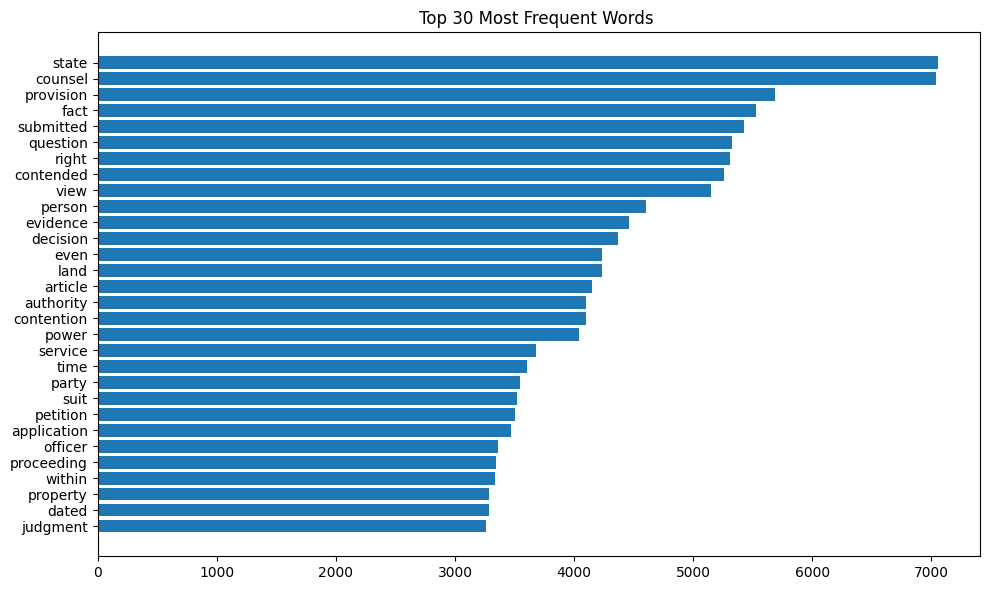

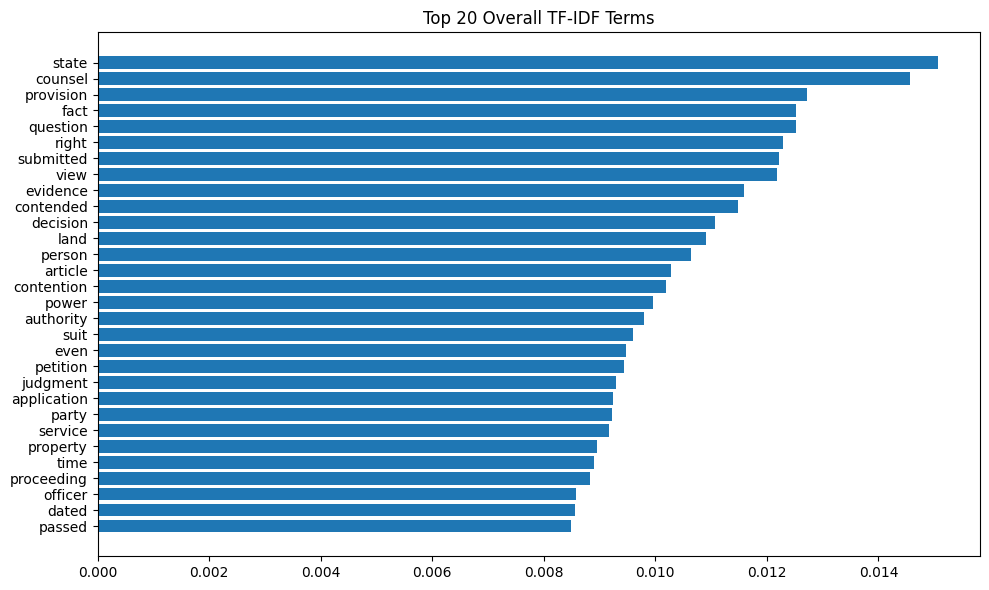

/tmp/ipykernel_37/2665603880.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


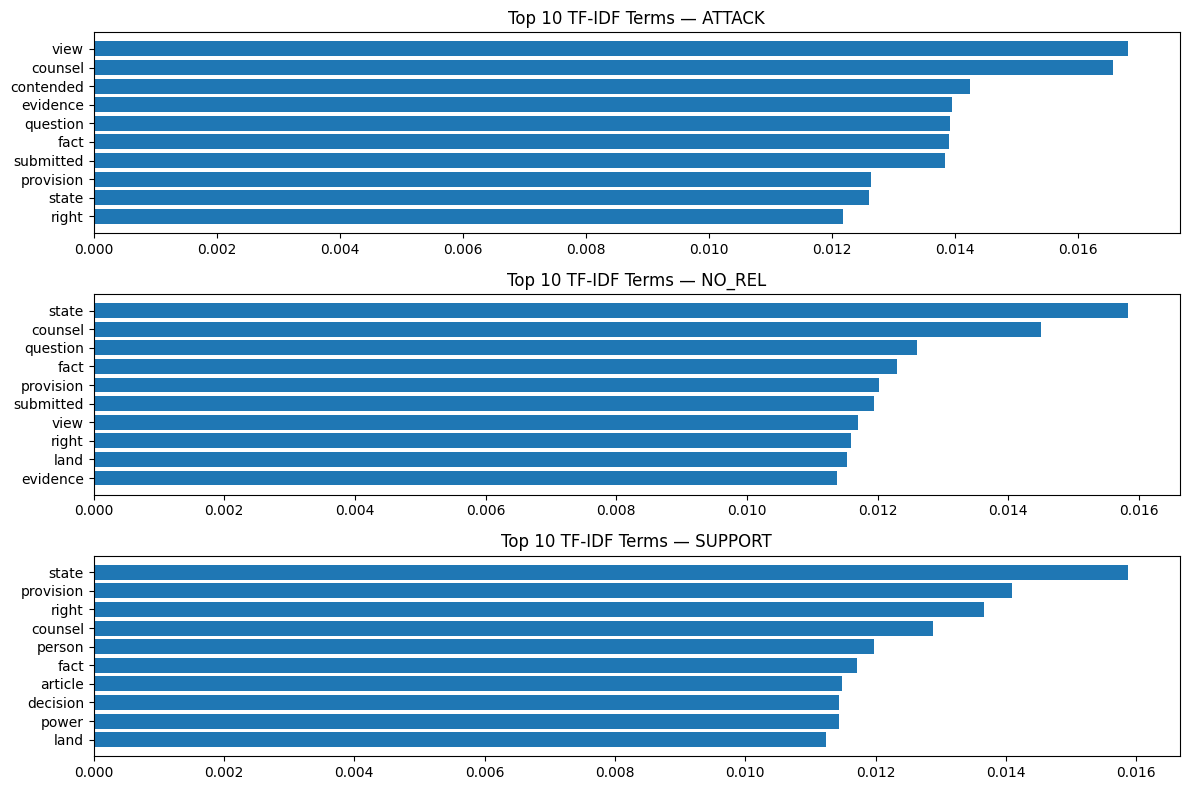


Saved final dataset → cleaned_legal_sentence_pairs_lemmatized.csv


In [49]:
# =========================================================
# Run
# =========================================================
if __name__ == "__main__":
    POS_PATH = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_PATH = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    main(POS_PATH, NEG_PATH)